In [1]:
%pip install matplotlib nltk==3.9.4 numpy==2.4.5 pandas==3.0.3 tqdm==4.67.3 wordfreq==3.1.1

  Using cached numpy-2.4.5-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB 495.5 kB/s eta 0:00:25
    --------------------------------------- 0.2/12.3 MB 1.4 MB/s eta 0:00:09
   - -------------------------------------- 0.6/12.3 MB 3.7 MB/s eta 0:00:04
   ---- ----------------------------------- 1.4/12.3 MB 6.8 MB/s eta 0:00:02
   ------- -------------------------------- 2.2/12.3 MB 9.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.3 MB 10.1 MB/s eta 0:00:01
   ------------ --------------------------- 3.9/12.3 MB 11.8 MB/s eta 0:00:01
   -------------- ------------------------- 4.6/12.3 MB 12.2 MB/s eta 0:00:01
   ----------------- ---------------------- 5.3/12.3 MB 12.5 MB/s eta 0:00:01
   ------------------- -------------------- 5.9/12.3 MB 12.6 MB/s eta 0:00:01
   ---------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.13.0 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.5 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import urllib.request
import re
import os

def load_benchls(url="https://raw.githubusercontent.com/qiang2100/BERT-LS/master/datasets/BenchLS.txt"):
    file_path = "benchls.txt"
    if not os.path.exists(file_path):
        urllib.request.urlretrieve(url, file_path)

    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 4:  # Zmienione na 4, bo musi być zdanie, słowo, indeks i min. 1 synonim
                continue

            sentence, target_word = parts[0], parts[1]
            # parts[2] to indeks słowa w zdaniu (np. ta nieszczęsna '2' lub '7') - POMIJAMY GO!

            # Zbieramy kandydatów dopiero od indeksu 3 w górę
            candidates = [re.sub(r'^\d+:', '', c).strip() for c in parts[3:] if c.strip()]

            data.append({
                "sentence": sentence,
                "target_word": target_word,
                "gold_substitutes": candidates
            })

    return pd.DataFrame(data)

# Przeładujcie tabelę:
df_benchls = load_benchls()

print(f"Wczytano {len(df_benchls)} wierszy.")
display(df_benchls.head(3))

Wczytano 929 wierszy.


,sentence,target_word,gold_substitutes
0,"in March 1992 , Linux version 0.95 was the fir...",pieces,"[parts, bits, components, information, element..."
1,much of the water carried by these streams is ...,diverted,"[redirected, rerouted, changed, moved, separat..."
2,Harry also becomes the worthy possessor of the...,possessor,"[owner, holder, keeper, buyer, master, teacher]"


In [3]:
import nltk
from nltk.corpus import wordnet
from wordfreq import word_frequency
from tqdm.notebook import tqdm

nltk.download(['wordnet', 'omw-1.4'], quiet=True)
tqdm.pandas(desc="Generowanie")

class WordNetSimplifier:
    def __init__(self, language='en'):
        self.language = language

    def simplify(self, word):
        word_clean = str(word).lower().strip()

        # Wyciąganie unikalnych synonimów
        synonyms = {
            lemma.name().replace('_', ' ').lower()
            for syn in wordnet.synsets(word_clean)
            for lemma in syn.lemmas()
        }

        # usuwanie oryginalnego słowa ze zbioru
        synonyms.discard(word_clean)

        if not synonyms:
            return word

        # wybór elementu z maksymalną częstością
        return max(synonyms, key=lambda w: word_frequency(w, self.language))


def precision_at_1(predictions, references):
    if not len(predictions):
        return 0.0

    correct = sum(
        1 for pred, refs in zip(predictions, references)
        if pred.lower().strip() in [r.lower().strip() for r in refs]
    )
    return correct / len(predictions)


# --- URUCHOMIENIE ---

simplifier = WordNetSimplifier()

df_benchls['baseline_pred'] = df_benchls['target_word'].progress_apply(simplifier.simplify)

p_at_1 = precision_at_1(df_benchls['baseline_pred'], df_benchls['gold_substitutes'])

print(f"\nWynik WordNet (P@1): {p_at_1:.2%}")
display(df_benchls[['target_word', 'baseline_pred', 'gold_substitutes']].head(10))

c:\Users\Kuba\AppData\Local\Programs\Python\Python312\Lib\site-packages\nltk\metrics\association.py:26: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.5)
  from scipy.stats import fisher_exact


Generowanie:   0%|          | 0/929 [00:00<?, ?it/s]


Wynik WordNet (P@1): 16.79%


,target_word,baseline_pred,gold_substitutes
0,pieces,while,"[parts, bits, components, information, element..."
1,diverted,entertained,"[redirected, rerouted, changed, moved, separat..."
2,possessor,owner,"[owner, holder, keeper, buyer, master, teacher]"
3,perils,risk,"[dangers, hazards, situations, danger, problem..."
4,retained,keep,"[kept, held, maintained, regained]"
5,residence,hall,"[home, house, dwelling, abode, owner, people]"
6,procured,secure,"[obtained, gathered, gotten, grabbed, acquired..."
7,convened,convene,"[called, assembled, gathered, held, started, m..."
8,vital,full of life,"[important, necessary, needed, essential, requ..."
9,acquired,get,"[gotten, gained, received, got, obtained, achi..."


In [4]:
from nltk.corpus import wordnet
from wordfreq import word_frequency

def debug_wordnet_pipeline(df, index):
    row = df.iloc[index]
    target = row['target_word']
    substitute = row['gold_substitutes']
    sentence = row['sentence']

    print(50 *"=")
    print(f"Analiza wiersza [{index}]")
    print(f"Zdanie: {sentence.replace(target, f'[{target.upper()}]')}")
    print(f"Trudne słowo:  {target}")
    print(f"Rekomendowane:  {substitute}\n")

    # 1. Analiza WordNet
    synsets = wordnet.synsets(target)
    if not synsets:
        print(f"Wynik: Brak wpisu w WordNet dla '{target}'. Zwracam oryginał.\n")
        return

    print(f"[KROK 1] Synsety WordNet ({len(synsets)} znalezionych):")
    synonyms = set()

    for syn in synsets:
        lemmas = [lemma.name().replace('_', ' ') for lemma in syn.lemmas()]
        print(f" - {syn.name()}: {syn.definition()}")
        print(f"   Lemmaty: {lemmas}")

        synonyms.update([
            l.lower() for l in lemmas
            if l.lower() != target.lower().strip()
        ])

    print(f"\nLiczba kandydatów: {len(synonyms)}")
    if not synonyms:
        print("Brak alternatywnych synonimów. Zwracam oryginał.\n")
        return

    # 2. Analiza częstości
    scored = sorted(
        [(syn, word_frequency(syn, 'en')) for syn in synonyms],
        key=lambda x: x[1],
        reverse=True
    )

    print("\n[KROK 2] Kandydaci o największej częstości występowania:")
    for i, (syn, freq) in enumerate(scored[:5], 1):
        print(f"  {i}. {syn:<15} ({freq:.6f})")

    # 3. Wybor
    best = scored[0][0]
    is_correct = best in substitute
    print( "\n" + 50* "-")
    print(f"\n[Wybor]")
    print(f"Predykcja: {best}")
    print(f"Status:    {'[PASS]' if is_correct else '[FAIL]'} (Precision@1 = {int(is_correct)})")
    print(50* "=" + "\n")


indeksy_do_sprawdzenia = [8, 340, 765]

for idx in indeksy_do_sprawdzenia:
    debug_wordnet_pipeline(df_benchls, idx)

Analiza wiersza [8]
Zdanie: photosynthesis is [VITAL] for life on Earth .
Trudne słowo:  vital
Rekomendowane:  ['important', 'necessary', 'needed', 'essential', 'required', 'critical', 'crucial']

[KROK 1] Synsety WordNet (4 znalezionych):
 - critical.s.01: urgently needed; absolutely necessary
   Lemmaty: ['critical', 'vital']
 - vital.s.02: performing an essential function in the living body
   Lemmaty: ['vital', 'life-sustaining']
 - full_of_life.s.01: full of spirit
   Lemmaty: ['full of life', 'lively', 'vital']
 - vital.s.04: manifesting or characteristic of life
   Lemmaty: ['vital']

Liczba kandydatów: 4

[KROK 2] Kandydaci o największej częstości występowania:
  1. full of life    (0.000237)
  2. critical        (0.000068)
  3. lively          (0.000007)
  4. life-sustaining (0.000004)

--------------------------------------------------

[Wybor]
Predykcja: full of life
Status:    [FAIL] (Precision@1 = 0)

Analiza wiersza [340]
Zdanie: in the Immunity Challenge , Koror had an e

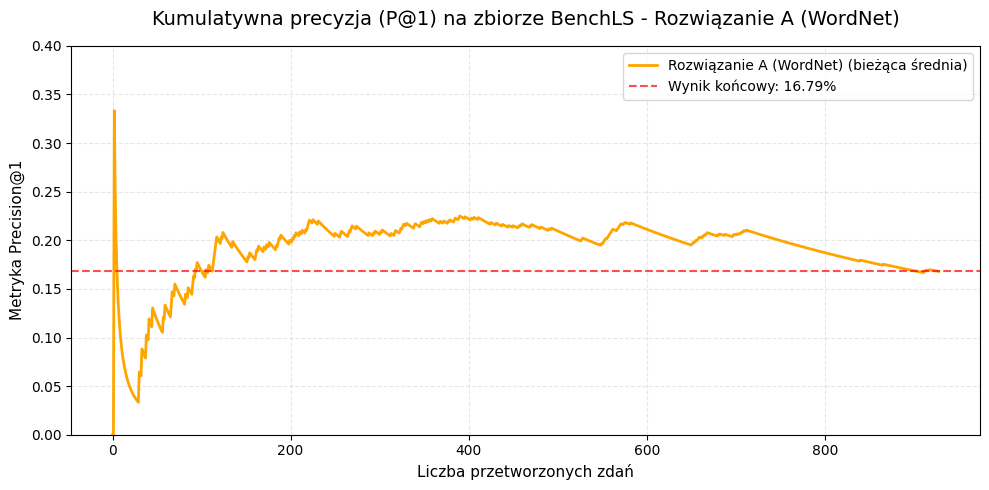

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cumulative_precision(df, prediction_column, model_name, color='orange'):
    """Rysuje wykres stabilizacji metryki P@1 w miarę przetwarzania zbioru."""

    # Tworzymy listę 1 (sukces) i 0 (porażka) dla każdego wiersza
    results = []
    for pred, refs in zip(df[prediction_column], df['gold_substitutes']):
        if str(pred).lower().strip() in [str(r).lower().strip() for r in refs]:
            results.append(1)
        else:
            results.append(0)

    # Obliczamy średnią kumulatywną (np. wynik po 10 zdaniach, po 11, po 12...)
    cumulative_precision = np.cumsum(results) / np.arange(1, len(results) + 1)
    final_score = cumulative_precision[-1]

    # Rysowanie wykresu
    plt.figure(figsize=(10, 5), dpi=100)
    plt.plot(cumulative_precision, color=color, linewidth=2, label=f'{model_name} (bieżąca średnia)')

    # Linia trendu końcowego
    plt.axhline(y=final_score, color='red', linestyle='--', alpha=0.7,
                label=f'Wynik końcowy: {final_score:.2%}')

    # Formatowanie wykresu
    plt.title(f'Kumulatywna precyzja (P@1) na zbiorze BenchLS - {model_name}', fontsize=14, pad=15)
    plt.xlabel('Liczba przetworzonych zdań', fontsize=11)
    plt.ylabel('Metryka Precision@1', fontsize=11)
    plt.ylim(0, 0.4) # Ustawiamy limit na 40%, żeby wykres był czytelny dla wyników baseline'u
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Wywołanie dla Rozwiązania A
plot_cumulative_precision(df_benchls, 'baseline_pred', 'Rozwiązanie A (WordNet)')